# Interpretation (SHAP & Feature Importance)

**Goal:** the project's second objective — **identify the key drivers of attrition so HR can act**. Phase 7 settled *how well* the deployed model predicts who leaves; this stage explains *why* it makes those calls, in terms a retention policy can be built on.

The deployed model is the bare tuned **RandomForest** confirmed in Phase 7 (test recall 0.830 at threshold 0.49). Because it is a tree ensemble, we use **SHAP's `TreeExplainer`** — an exact, additive attribution method: every prediction decomposes into a base rate plus a signed per-feature contribution, so the explanations are faithful to the model rather than an approximation of it.

All explanations are computed on the **294-row held-out test set** — the same unbiased sample Phase 7 reported on, never seen during training. We read drivers three ways (SHAP, impurity, permutation) so agreement, not a single method, justifies each conclusion, then drill from the global picture down to two individual employees and out to the retention levers the drivers imply.

## 1. Setup

The Phase 7 plotting/IO stack (`matplotlib`, `seaborn`, `joblib`, `numpy`, `pandas`) plus the two new tools this stage needs: **`shap`** for attributions and `sklearn.inspection.permutation_importance` (with `recall_score`) for a model-agnostic importance cross-check. `RANDOM_STATE = 42`, `PROC = Path('processed')` (the `processed/` folder sits inside `notebooks/`), and `FIG = Path('outputs')` all match every earlier stage.

> **Prerequisite:** `shap` is a new dependency for the project â€” install it once with `pip install shap` before running this notebook.

In [1]:
# Cell 1 — Imports & setup
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 42
PROC = Path('processed')          # processed/ lives inside notebooks/
FIG = Path('outputs')             # figures saved here for reuse in reports/slides
FIG.mkdir(exist_ok=True)

## 2. Load the deployed model, test set, and threshold

`final_model.joblib` is the confirmed RandomForest; `final_evaluation.joblib` carries its deployment **threshold (0.49)**, fixed on OOF data in Phase 6 and never re-tuned on test.

One subtlety drives the rest of the notebook: the 30 continuous columns in `X_test` are in **StandardScaler space**. SHAP *values* are valid regardless of scaling, but z-scored axes are unreadable, so we keep `X_test_display` â€” a copy with the scaled columns inverse-transformed back to real units (years, dollars, levels) â€” purely for plotting. The model continues to score the scaled `X_test`. We also precompute the deployment `proba`/`pred` here for the local case studies.

In [2]:
# Cell 2 — Load the deployed model, the held-out test set, and the deployment threshold
# The interpretation runs on the exact estimator Phase 7 confirmed for deployment
# (a bare RandomForestClassifier) and on the 294-row test set it was never trained on.
final_model = joblib.load(PROC / 'models' / 'final_model.joblib')
X_test = pd.read_parquet(PROC / 'X_test.parquet')
y_test = pd.read_parquet(PROC / 'y_test.parquet')['Attrition']

# Phase 7 metadata carries the deployed model name and the threshold fixed on OOF data in Phase 6.
final_eval = joblib.load(PROC / 'final_evaluation.joblib')
threshold = float(final_eval['threshold'])

# The 30 continuous columns sit in StandardScaler space. SHAP *values* are valid as-is, but plot
# axes/colour are unreadable in z-scores, so we keep a display copy in original units (years,
# dollars, levels) for every plot. The model still scores the scaled X_test.
scaler = joblib.load(PROC / 'scaler.joblib')
scale_cols = joblib.load(PROC / 'scale_cols.joblib')
X_test_display = X_test.copy()
X_test_display[scale_cols] = scaler.inverse_transform(X_test[scale_cols])

# Deployment predictions, used for the local case studies below.
proba = final_model.predict_proba(X_test)[:, 1]
pred = (proba >= threshold).astype(int)

print(f'Model: {type(final_model).__name__} | deployed: {final_eval["selected_model"]} @ {threshold:.2f}')
print(f'X_test {X_test.shape} | attrition {y_test.mean():.3f} | flagged {int(pred.sum())} / {len(pred)}')

Model: RandomForestClassifier | deployed: RandomForest @ 0.49
X_test (294, 56) | attrition 0.160 | flagged 124 / 294


## 3. Helpers

`savefig(name)` writes the current figure to `outputs/<name>.png` at 150 dpi, exactly as in Phase 7. `normalize_shap` and `normalize_base` absorb a version difference in SHAP: older releases return `shap_values` as a list `[class0, class1]`, newer ones as a `(n, features, n_classes)` array. Both helpers collapse that to the **positive-class ("Leave")** values â€” a 2-D matrix and a scalar base â€” so the rest of the notebook is version-agnostic. Defined inline because helpers do not carry across stage notebooks.

In [3]:
# Cell 3 — Helpers
# Defined inline because helpers do not carry across stage notebooks.
def savefig(name):
    """Save the current figure to outputs/<name>.png for reuse in reports/slides."""
    plt.savefig(FIG / f'{name}.png', dpi=150, bbox_inches='tight')


def normalize_shap(raw):
    """Positive-class SHAP values as a 2-D (n_samples, n_features) array, across shap versions.

    Old API returns a list [class0, class1]; newer returns a (n, features, n_classes) array.
    """
    if isinstance(raw, list):                 # old API: [class0, class1]
        return np.asarray(raw[1])
    arr = np.asarray(raw)
    if arr.ndim == 3:                          # new API: (n, features, n_classes)
        return arr[:, :, 1]
    return arr                                 # already (n, features)


def normalize_base(raw):
    """Scalar base (expected) value for the positive class, across shap versions."""
    if isinstance(raw, (list, np.ndarray)):
        vals = np.ravel(np.asarray(raw, dtype=float))
        return float(vals[1]) if vals.size > 1 else float(vals[0])
    return float(raw)

## 4. Build the explainer and compute SHAP values

`TreeExplainer(final_model)` applies **directly** â€” the deployed model is a plain `RandomForestClassifier`, not a pipeline, so there is nothing to unwrap. Output is in **probability units**: for any employee, `base_value + sum(SHAP) = predicted P(Leave)`, where the base value is the model's mean predicted attrition probability across the sample. We bundle the values, the scalar base, and the **display** features into a single `shap.Explanation` so the plotting API below renders readable axes.

In [4]:
# Cell 4 — Build the TreeExplainer and compute SHAP values on the test set
# RandomForest is a bare sklearn estimator, so TreeExplainer applies directly (no pipeline to
# unwrap). Output is in probability units: base + sum(shap) = predicted P(Leave).
explainer = shap.TreeExplainer(final_model)
sv = normalize_shap(explainer.shap_values(X_test))         # (294, 56) positive-class contributions
base = normalize_base(explainer.expected_value)            # mean P(Leave) over the background

# Bundle values + display features into one Explanation object for the SHAP plotting API.
expl = shap.Explanation(
    values=sv,
    base_values=np.full(len(X_test), base),
    data=X_test_display.values,
    feature_names=list(X_test.columns),
)
print(f'SHAP values: {sv.shape} | base value (mean P(Leave)): {base:.3f}')

SHAP values: (294, 56) | base value (mean P(Leave)): 0.608


## 5. Global importance — mean |SHAP|

The headline ranking: average absolute SHAP contribution per feature, i.e. how much each feature moves the attrition prediction on average. This is the most defensible single answer to "what drives attrition here." The bar chart is saved as `shap_bar.png`, and the same numbers are captured in a `shap_imp` table that seeds the dependence plots and the business synthesis.

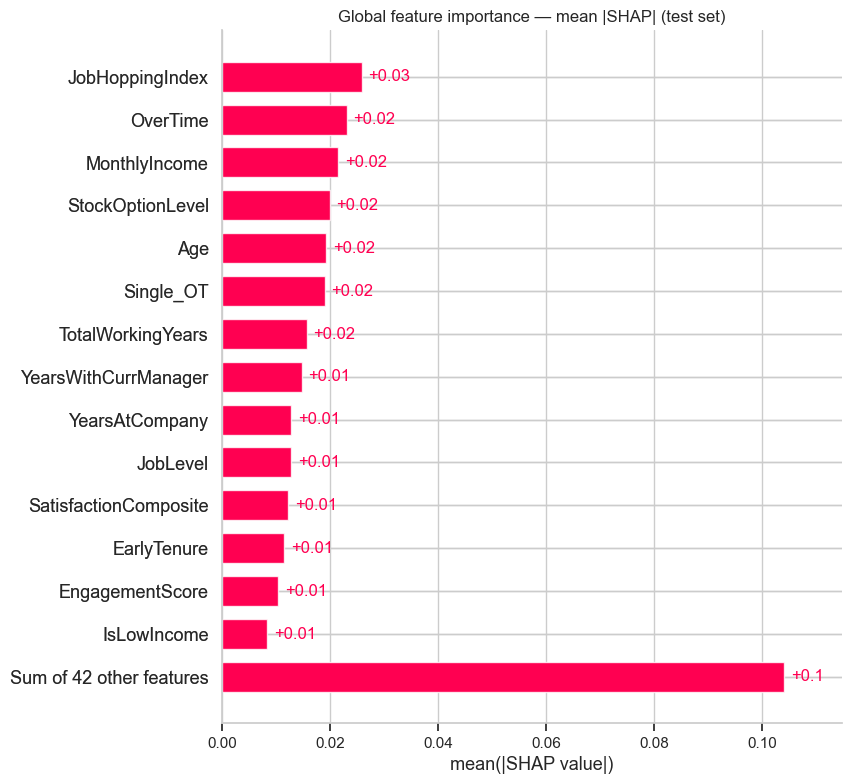

              feature  shap_mean_abs
      JobHoppingIndex          0.026
             OverTime          0.023
        MonthlyIncome          0.021
     StockOptionLevel          0.020
                  Age          0.019
            Single_OT          0.019
    TotalWorkingYears          0.016
 YearsWithCurrManager          0.015
       YearsAtCompany          0.013
             JobLevel          0.013
SatisfactionComposite          0.012
          EarlyTenure          0.012
      EngagementScore          0.010
          IsLowIncome          0.008
 MaritalStatus_Single          0.008


In [5]:
# Cell 5 — Global importance: mean |SHAP| per feature
# The single most defensible ranking of which features move the model's attrition prediction most.
shap.plots.bar(expl, max_display=15, show=False)
plt.title('Global feature importance — mean |SHAP| (test set)')
savefig('shap_bar')
plt.show()

shap_mean_abs = np.abs(sv).mean(axis=0)
shap_imp = (
    pd.DataFrame({'feature': X_test.columns, 'shap_mean_abs': shap_mean_abs})
    .sort_values('shap_mean_abs', ascending=False)
    .reset_index(drop=True)
)
print(shap_imp.head(15).to_string(index=False))

## 6. Direction of effect â€” beeswarm

Magnitude alone doesn't say *which way* a feature pushes. The beeswarm plots every employee's SHAP value per feature, coloured by the feature's value (red high, blue low), so the sign is legible: we expect `OverTime = 1`, low income, and short tenure to sit on the Leave side, high satisfaction/engagement on the Stay side. This is the figure that turns "important" into "important *and* in this direction." Saved as `shap_summary.png`.

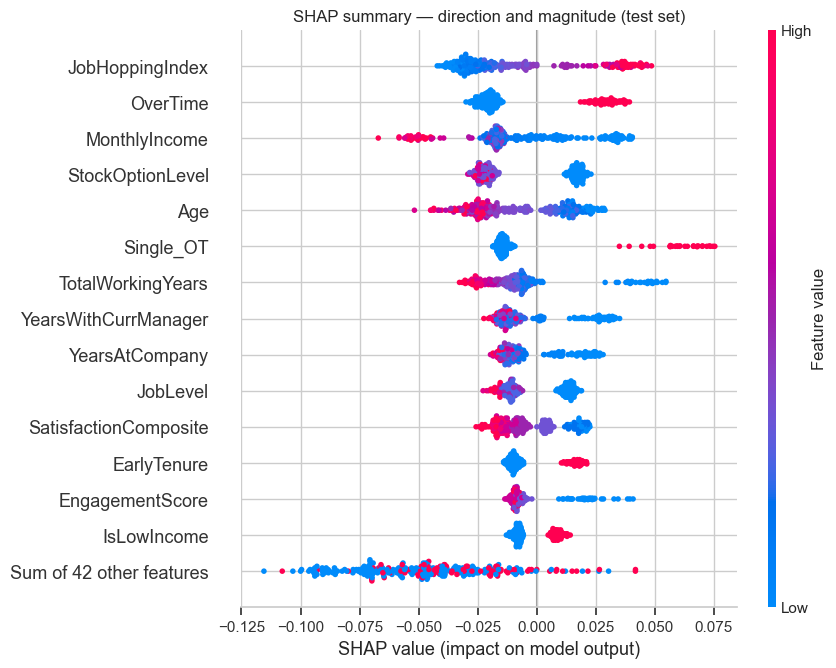

In [6]:
# Cell 6 — Direction of effect: SHAP beeswarm summary
# Beyond magnitude, this shows the *sign*: for each feature, whether high values (red) push toward
# Leave or Stay. E.g. OverTime=1 and low income should sit on the Leave side.
shap.plots.beeswarm(expl, max_display=15, show=False)
plt.title('SHAP summary — direction and magnitude (test set)')
savefig('shap_summary')
plt.show()

## 7. Three views of importance

SHAP is one lens; two others guard against its blind spots. **Impurity** importance (the model's own `feature_importances_`) is cheap but biased toward high-cardinality / many-split features. **Permutation** importance is model-agnostic and measured here on the **objective metric â€” recall at the deployed 0.49 threshold** on held-out data â€” answering "how much does shuffling this feature cost our ability to catch leavers?" **SHAP mean|abs|** is the per-prediction attribution from above. We min-max each to a common 0â€“1 scale and plot the top twelve side by side: features the three methods rank together are the drivers we can trust. Saved as `importance_comparison.png`, with the full numeric table printed.

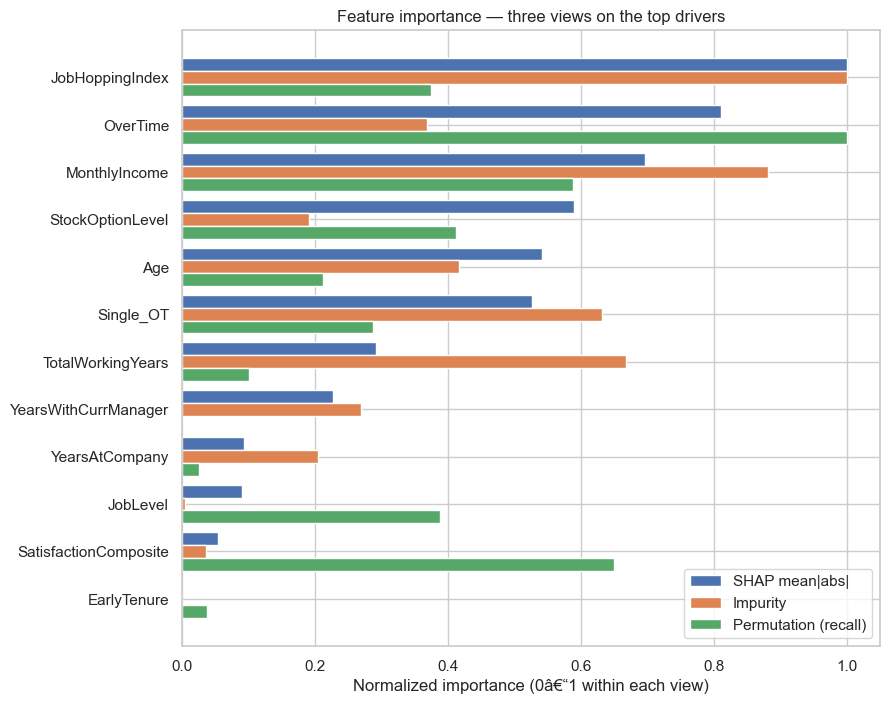

              feature  shap_mean_abs  impurity  perm_mean  perm_std
      JobHoppingIndex          0.026     0.082      0.022     0.022
             OverTime          0.023     0.049      0.076     0.017
        MonthlyIncome          0.021     0.076      0.040     0.027
     StockOptionLevel          0.020     0.040      0.026     0.011
                  Age          0.019     0.052      0.009     0.012
            Single_OT          0.019     0.063      0.015     0.012
    TotalWorkingYears          0.016     0.065     -0.001     0.016
 YearsWithCurrManager          0.015     0.044     -0.010     0.014
       YearsAtCompany          0.013     0.041     -0.007     0.015
             JobLevel          0.013     0.031      0.023     0.024
SatisfactionComposite          0.012     0.032      0.046     0.026
          EarlyTenure          0.012     0.030     -0.006     0.010


In [7]:
# Cell 7 — Three views of importance: SHAP vs impurity vs permutation
# impurity is split-count / cardinality biased; permutation is model-agnostic and scored on the
# objective metric (recall) on held-out data; SHAP is per-prediction attribution. Where all three
# agree, we can trust the driver.
impurity = pd.Series(final_model.feature_importances_, index=X_test.columns)


def recall_scorer(estimator, X, y):
    """Permutation scorer that honours the deployed threshold, not the default 0.5."""
    p = estimator.predict_proba(X)[:, 1]
    return recall_score(y, (p >= threshold).astype(int))


perm = permutation_importance(
    final_model, X_test, y_test, scoring=recall_scorer,
    n_repeats=20, random_state=RANDOM_STATE,
)

importance = (
    pd.DataFrame({
        'feature': X_test.columns,
        'shap_mean_abs': shap_mean_abs,
        'impurity': impurity.values,
        'perm_mean': perm.importances_mean,
        'perm_std': perm.importances_std,
    })
    .sort_values('shap_mean_abs', ascending=False)
    .reset_index(drop=True)
)


def _minmax(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0.0


top = importance.head(12).copy()
for col in ['shap_mean_abs', 'impurity', 'perm_mean']:
    top[col + '_n'] = _minmax(top[col])

order = top.iloc[::-1]                  # largest driver at the top of the chart
y_pos = np.arange(len(order))
h = 0.27
plt.figure(figsize=(9, 8))
plt.barh(y_pos + h, order['shap_mean_abs_n'], height=h, label='SHAP mean|abs|')
plt.barh(y_pos,     order['impurity_n'],      height=h, label='Impurity')
plt.barh(y_pos - h, order['perm_mean_n'],     height=h, label='Permutation (recall)')
plt.yticks(y_pos, order['feature'])
plt.xlabel('Normalized importance (0â€“1 within each view)')
plt.title('Feature importance — three views on the top drivers')
plt.legend(loc='lower right')
savefig('importance_comparison')
plt.show()

print(importance.head(12).to_string(index=False))

## 8. Dependence plots

For the top six drivers, how the SHAP contribution varies across the feature's range, with an auto-selected interaction feature as the colour. Features are passed in **original units**, so the x-axes read in years, dollars, and levels â€” e.g. whether risk falls smoothly with income or drops off a cliff below a band, and where overtime or early tenure flips the contribution positive. Saved as `shap_dependence.png`.

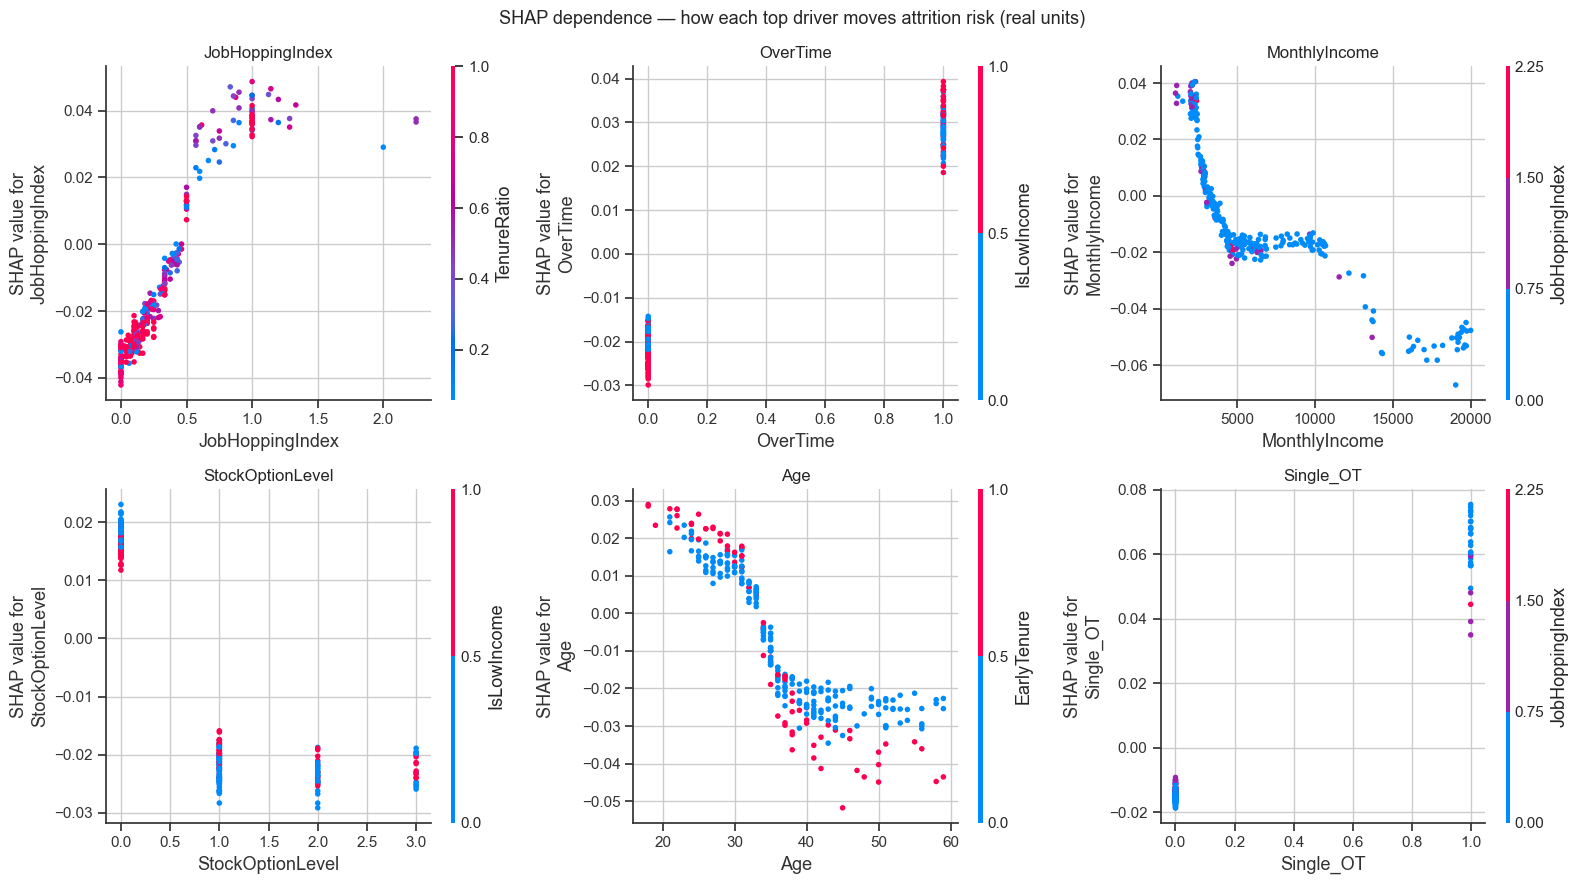

In [8]:
# Cell 8 — Dependence plots for the top drivers (real units)
# How risk moves across the range of each driver, with an auto-chosen interaction colour. Features
# are passed in original units so the x-axes read in years / dollars / levels rather than z-scores.
top_feats = shap_imp['feature'].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.ravel(), top_feats):
    shap.dependence_plot(feat, sv, X_test_display, ax=ax, show=False, interaction_index='auto')
    ax.set_title(feat)
fig.suptitle('SHAP dependence — how each top driver moves attrition risk (real units)', fontsize=13)
fig.tight_layout()
savefig('shap_dependence')
plt.show()

## 9. Local case studies

Global patterns made concrete on two individuals, via **waterfall** plots that walk from the base rate to the final prediction one feature push at a time. We pick the **most confidently caught leaver** (true positive) to show what the model keys on when it gets a save right, and the **most under-scored missed leaver** (the false negative with the lowest predicted probability) to show where its signals fall short â€” the honest counterpart to the success story. Saved as `shap_waterfall_tp.png` and `shap_waterfall_fn.png`.

Caught leaver (TP): row 200, proba 0.931 >= 0.49
Missed leaver (FN): row 240, proba 0.287 <  0.49


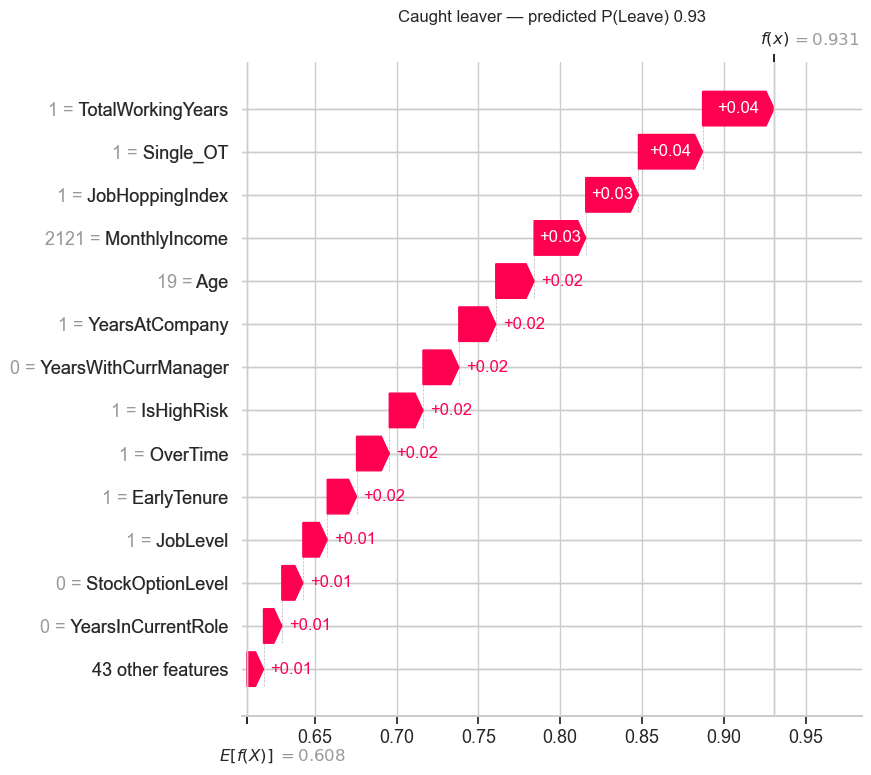

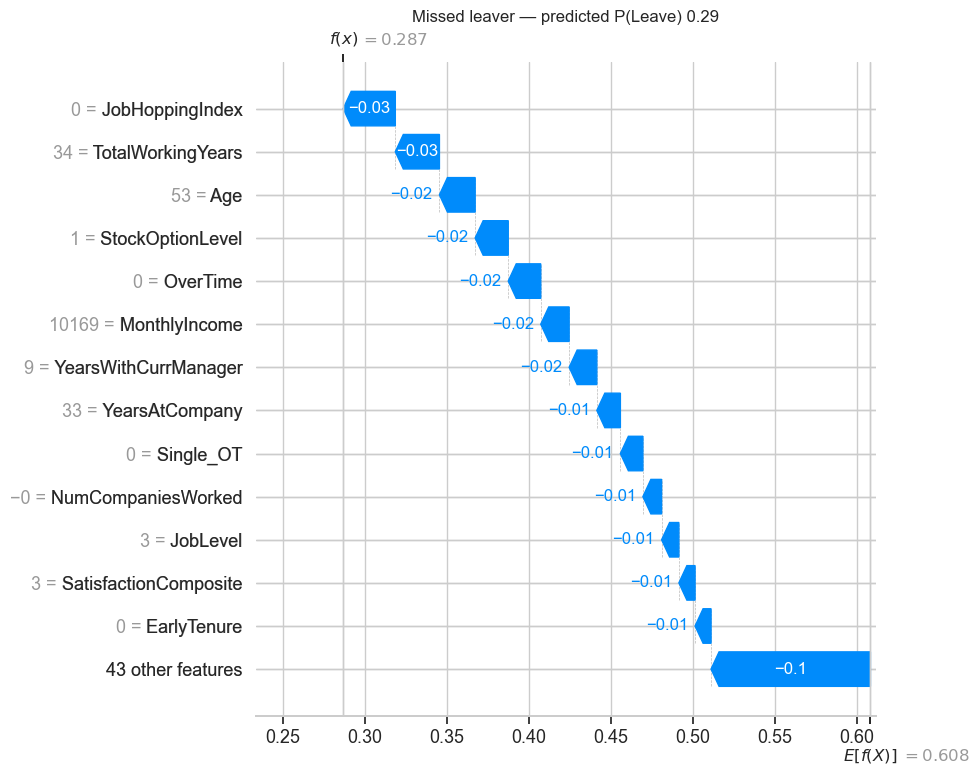

In [9]:
# Cell 9 — Local case studies: a caught leaver vs a missed leaver
# Waterfall plots decompose two individual predictions into per-feature pushes from the base rate.
# We pick the most confidently caught leaver (TP) and the most under-scored missed leaver (FN) to
# show both what the model keys on and where it fails.
y = y_test.values
tp_pos = np.where((pred == 1) & (y == 1))[0]      # caught leavers
fn_pos = np.where((pred == 0) & (y == 1))[0]      # missed leavers

tp_i = int(tp_pos[np.argmax(proba[tp_pos])])      # highest-confidence catch
fn_i = int(fn_pos[np.argmin(proba[fn_pos])])      # most under-scored miss

print(f'Caught leaver (TP): row {tp_i}, proba {proba[tp_i]:.3f} >= {threshold:.2f}')
print(f'Missed leaver (FN): row {fn_i}, proba {proba[fn_i]:.3f} <  {threshold:.2f}')

shap.plots.waterfall(expl[tp_i], max_display=14, show=False)
plt.title(f'Caught leaver — predicted P(Leave) {proba[tp_i]:.2f}')
savefig('shap_waterfall_tp')
plt.show()

shap.plots.waterfall(expl[fn_i], max_display=14, show=False)
plt.title(f'Missed leaver — predicted P(Leave) {proba[fn_i]:.2f}')
savefig('shap_waterfall_fn')
plt.show()

## 10. Business synthesis — drivers to levers

The bridge from model to policy: each top driver mapped to the retention action it implies, tied back to the EDA themes and the engineered risk signals (overtime, peer-relative and absolute income, early tenure, `Single Ã— OT`, low engagement, promotion overdue). The printed driver â†’ lever table is the artifact HR actually consumes — a ranked, actionable shortlist of where intervention is most likely to retain at-risk, high-value staff.

In [10]:
# Cell 10 — Business synthesis: drivers -> retention levers
# Translate the top SHAP drivers into the HR actions they imply, tying each back to the EDA themes
# and the engineered risk signals the model learned to use.
LEVER = {
    'OverTime': 'Cap sustained overtime; redistribute load on chronically over-extended roles.',
    'MonthlyIncome': 'Review pay for below-band staff in high-attrition roles.',
    'IncomePerLevel': 'Audit pay-vs-job-level compression; fix under-levelled high performers.',
    'PeerRelativeIncome': 'Benchmark pay against role+level peers; close large negative gaps.',
    'IsLowIncome': 'Prioritise the lowest-income tercile for retention review.',
    'Age': 'Tailor offers: career pathing for younger staff, flexibility for older.',
    'TotalWorkingYears': 'Watch early-career, low-experience joiners most closely.',
    'YearsAtCompany': 'Strengthen first-two-year onboarding and check-ins.',
    'EarlyTenure': 'Front-load mentoring during the first two years.',
    'YearsInCurrentRole': 'Offer lateral moves / growth before stagnation sets in.',
    'YearsWithCurrManager': 'Provide manager-relationship and transition support.',
    'YearsSinceLastPromotion': 'Set clear promotion timelines; flag overdue cases.',
    'PromotionOverdue': 'Review staff 6+ years without a promotion.',
    'StockOptionLevel': 'Extend equity to retain at-risk mid-level staff.',
    'JobSatisfaction': 'Act on low job-satisfaction survey scores.',
    'EnvironmentSatisfaction': 'Improve team/environment for low scorers.',
    'JobInvolvement': 'Increase ownership and meaningful work.',
    'WorkLifeBalance': 'Protect work-life balance, especially under overtime.',
    'SatisfactionComposite': 'Target the lowest composite-satisfaction segment.',
    'EngagementScore': 'Boost involvement and balance jointly.',
    'IsLowEngagement': 'Intervene on the low-involvement / low-balance group.',
    'DistanceFromHome': 'Offer remote/hybrid or relocation support for long commutes.',
    'Single_OT': 'Single employees on overtime are highest-risk — protect their balance.',
    'FreqTravel_OT': 'Frequent travel plus overtime compounds risk; rebalance both.',
    'IsHighRisk': 'Composite high-risk flag — prioritise for proactive outreach.',
    'MaritalStatus_Single': 'Single staff churn more; tailor engagement.',
    'NumCompaniesWorked': 'Prior job-hopping signals flight risk; invest early.',
    'JobHoppingIndex': 'High job-hop rate — secure with growth and recognition.',
    'BusinessTravel': 'Reduce travel burden where it predicts exits.',
}

drivers = shap_imp['feature'].head(10).tolist()
print(f'{"driver":26s} {"SHAP":>7s}  retention lever')
print('-' * 92)
for f in drivers:
    s = shap_imp.loc[shap_imp['feature'] == f, 'shap_mean_abs'].iloc[0]
    print(f'{f:26s} {s:7.3f}  {LEVER.get(f, "(review in context)")}')

driver                        SHAP  retention lever
--------------------------------------------------------------------------------------------
JobHoppingIndex              0.026  High job-hop rate — secure with growth and recognition.
OverTime                     0.023  Cap sustained overtime; redistribute load on chronically over-extended roles.
MonthlyIncome                0.021  Review pay for below-band staff in high-attrition roles.
StockOptionLevel             0.020  Extend equity to retain at-risk mid-level staff.
Age                          0.019  Tailor offers: career pathing for younger staff, flexibility for older.
Single_OT                    0.019  Single employees on overtime are highest-risk — protect their balance.
TotalWorkingYears            0.016  Watch early-career, low-experience joiners most closely.
YearsWithCurrManager         0.015  Provide manager-relationship and transition support.
YearsAtCompany               0.013  Strengthen first-two-year onboarding a

## 11. Persist artifacts

Three outputs for downstream reuse and reporting: `shap_importance.parquet` (the full feature ranking with SHAP, impurity, and permutation measures plus per-method ranks), `shap_values_test.parquet` (the raw SHAP matrix aligned to the test index, for any custom slicing), and `interpretation.joblib` (the model, threshold, method, base value, and top-ten drivers as a compact summary). The six figures already sit in `outputs/`. This closes the pipeline: EDA â†’ preprocessing â†’ features â†’ imbalance â†’ modeling â†’ tuning â†’ evaluation â†’ interpretation.

In [11]:
# Cell 11 — Persist interpretation artifacts
# Importance table with all three measures + per-measure ranks.
shap_importance = importance.copy()
shap_importance['shap_rank'] = shap_importance['shap_mean_abs'].rank(ascending=False).astype(int)
shap_importance['impurity_rank'] = shap_importance['impurity'].rank(ascending=False).astype(int)
shap_importance['perm_rank'] = shap_importance['perm_mean'].rank(ascending=False).astype(int)
shap_importance.to_parquet(PROC / 'shap_importance.parquet', index=False)

# The raw SHAP value matrix, aligned to the test index, for any downstream reuse.
sv_df = pd.DataFrame(sv, columns=X_test.columns, index=X_test.index)
sv_df.to_parquet(PROC / 'shap_values_test.parquet')

joblib.dump({
    'model': 'RandomForest',
    'threshold': threshold,
    'method': 'SHAP TreeExplainer',
    'base_value': float(base),
    'top_drivers': shap_imp['feature'].head(10).tolist(),
    'sample': 'test (294)',
}, PROC / 'interpretation.joblib')

print(f'Saved shap_importance.parquet, shap_values_test.parquet, interpretation.joblib to {PROC.resolve()}')
print(f'Saved 6 figures to {FIG.resolve()}: shap_bar, shap_summary, importance_comparison, '
      f'shap_dependence, shap_waterfall_tp, shap_waterfall_fn')

Saved shap_importance.parquet, shap_values_test.parquet, interpretation.joblib to C:\Users\zeesh\Documents\GitHub\Attrition Prediction Model\notebooks\processed
Saved 6 figures to C:\Users\zeesh\Documents\GitHub\Attrition Prediction Model\notebooks\outputs: shap_bar, shap_summary, importance_comparison, shap_dependence, shap_waterfall_tp, shap_waterfall_fn
